In [79]:
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
# Load the model
model = cobra.io.read_sbml_model("../model.xml")

In [81]:
ecoli_model = cobra.io.read_sbml_model("/Users/helenscott/Documents/PhD/Segre-lab/GEM-repos/ecoli/iJO1366.xml")

In [ ]:
# Define a minimal media without C or N
minimal_media = {
    "EX_cpd00058_e0": 1000,  # Cu2+_e0
    "EX_cpd00007_e0": 20,  # O2_e0
    "EX_cpd00971_e0": 1000,  # Na+_e0
    "EX_cpd00063_e0": 1000,  # Ca2+_e0
    "EX_cpd00048_e0": 1000,  # Sulfate_e0
    "EX_cpd10516_e0": 1000,  # fe3_e0
    "EX_cpd00254_e0": 1000,  # Mg_e0
    "EX_cpd00009_e0": 1000,  # Phosphate_e0
    "EX_cpd00205_e0": 1000,  # K+_e0
    "EX_cpd00099_e0": 1000,  # Cl-_e0
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
    "EX_cpd00001_e0": 1000,  # H2O_e0
    "EX_cpd00034_e0": 1000,  # Zn2+_e0
    "EX_cpd00149_e0": 1000,  # Co2+_e0
}

In [83]:
# Define carbon sources to test
c_source = {"Glucose": {"modelseed": "EX_cpd00027_e0", "bigg": "EX_glc__D_e"},
            "Acetate": {"modelseed": "EX_cpd00029_e0", "bigg": "EX_ac_e"},
            "Pyruvate": {"modelseed": "EX_cpd00020_e0", "bigg": "EX_pyr_e"},
            "Succinate": {"modelseed": "EX_cpd00036_e0", "bigg": "EX_succ_e"}}

In [84]:
# Define nitrogen sources to test
n_source = {"Ammonia": {"modelseed": "EX_cpd00013_e0", "bigg": "EX_nh4_e"},
            "Nitrate": {"modelseed": "EX_cpd00209_e0", "bigg": "EX_no3_e"}}

In [24]:
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
p_id = "EX_cpd00067_e0"
for p_limit in [0, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[p_id] = p_limit

            # Set the minimal media
            model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Proton Limit": p_limit,
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"]
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

In [25]:
results

,Carbon Source,Nitrogen Source,Proton Limit,Media,Growth Rate
0,Glucose,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",1.253265
1,Glucose,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.817989
2,Acetate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.508805
3,Acetate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.000000
4,Pyruvate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.973891
5,Pyruvate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.453345
6,Succinate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.452971
7,Succinate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.000000
8,Glucose,Ammonia,1000,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",1.253265
9,Glucose,Nitrate,1000,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.892375


In [29]:
results.head().to_markdown()

"|    | Carbon Source   | Nitrogen Source   |   Proton Limit | Media                                                                                                                                                                                                                                                                                                                                                                                                               |   Growth Rate |\n|---:|:----------------|:------------------|---------------:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------:|\n|  0 | Glucose         | Ammo

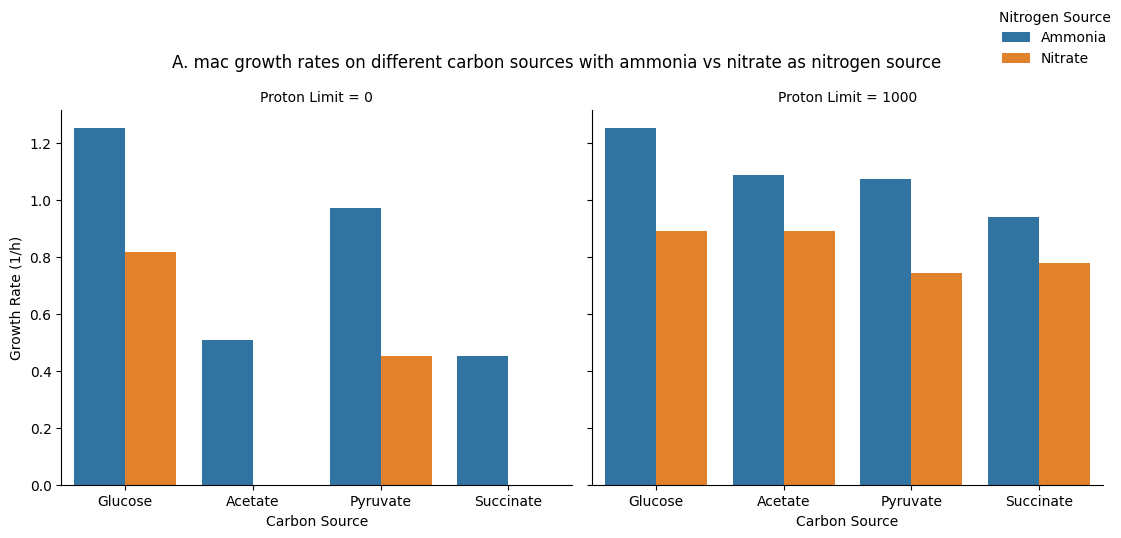

In [48]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Proton Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

## E. coli

In [38]:
ecoli_minimal_media = {
 'EX_co2_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_cbl1_e': 0.01,
 'EX_ni2_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_pi_e': 1000.0,
 'EX_zn2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_slnt_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_fe3_e': 1000.0
 }

In [46]:
# Make a list to store results
ecoli_results_list = []

# For each carbon and nitrogen source, and proton limit test growth
p_id = "EX_h_e"
for p_limit in [0, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["bigg"]
        # Find the metabolite for the carbon source
        carbon_metabolite = ecoli_model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["bigg"]

            # Create a copy of the minimal media
            media = ecoli_minimal_media.copy()

            # Add the carbon, nitrogen, and protons to the medium
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000
            media[p_id] = p_limit
            
            # Set the minimal media
            ecoli_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(ecoli_model)
            
            # Store the results
            ecoli_results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Proton Limit": p_limit,
                "Media": media,
                "Growth Rate": solution.fluxes["BIOMASS_Ec_iJO1366_core_53p95M"]
            })

# Create a dataframe from the list of results
ecoli_results = pd.DataFrame(ecoli_results_list)

In [47]:
ecoli_results

,Carbon Source,Nitrogen Source,Proton Limit,Media,Growth Rate
0,Glucose,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372
1,Glucose,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.779840
2,Acetate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.534681
3,Acetate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.386570
4,Pyruvate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.617273
5,Pyruvate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.448744
6,Succinate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.521589
7,Succinate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.374848
8,Glucose,Ammonia,1000,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372
9,Glucose,Nitrate,1000,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.849220


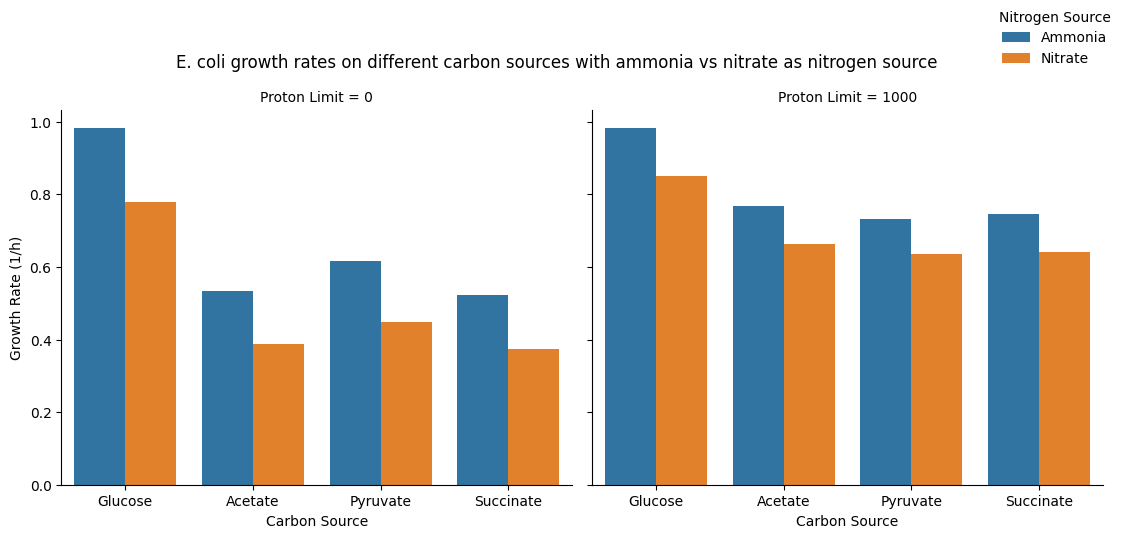

In [49]:
# Plot a paired bar chart of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source
g = sns.catplot(
    data=ecoli_results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Proton Limit",
)
g.fig.suptitle("E. coli growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()